In [4]:
print("hello")

hello


In [6]:
import os

base_dir = "train"   # mee train folder path

for disease in os.listdir(base_dir):
    folder = os.path.join(base_dir, disease)
    if os.path.isdir(folder):
        print(disease, "->", len(os.listdir(folder)), "images")


Acral_Lentiginous_Melanoma -> 735 images
blue_finger -> 603 images
clubbing -> 767 images
Healthy_Nail -> 323 images
Onychogryphosis -> 677 images
pitting -> 639 images


In [7]:
import os

# Dataset folder path
train = "train"
validation = "validation"

# Folders check chesam
print("Train folders:", os.listdir(train))
print("Validation folders:", os.listdir(validation))



Train folders: ['Acral_Lentiginous_Melanoma', 'blue_finger', 'clubbing', 'Healthy_Nail', 'Onychogryphosis', 'pitting']
Validation folders: ['Acral_Lentiginous_Melanoma', 'blue_finger', 'clubbing', 'Healthy_Nail', 'Onychogryphosis', 'pitting']


In [8]:
pip install tensorflow



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import tensorflow as tf
print(tf.__version__)


2.20.0


In [8]:
train = "train"
validation = "validation"


In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    validation,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)


Found 3744 images belonging to 6 classes.
Found 116 images belonging to 6 classes.


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = train_generator.num_classes

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


c:\Users\PC\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [13]:
epochs = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=epochs
)


Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.2919 - loss: 1.6530 - val_accuracy: 0.3966 - val_loss: 1.4449
Epoch 2/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 111s 947ms/step - accuracy: 0.4014 - loss: 1.3936 - val_accuracy: 0.4569 - val_loss: 1.3050
Epoch 3/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 111s 949ms/step - accuracy: 0.4466 - loss: 1.2982 - val_accuracy: 0.4741 - val_loss: 1.3667
Epoch 4/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 110s 942ms/step - accuracy: 0.4701 - loss: 1.2835 - val_accuracy: 0.5000 - val_loss: 1.2773
Epoch 5/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 112s 957ms/step - accuracy: 0.4952 - loss: 1.2240 - val_accuracy: 0.5000 - val_loss: 1.3970
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.5016 - loss: 1.2093 - val_accuracy: 0.4914 - val_loss: 1.3763
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 113s 960ms/step - accuracy: 0.4685 - loss: 1.3086 - val_accuracy: 0.4224 - val_loss: 1.4137
Epoch 8/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 110s 937ms/step - accuracy: 0.5016 - loss:

In [15]:
loss, accuracy = model.evaluate(val_generator)
print("Final Validation Accuracy:", accuracy)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.5259 - loss: 1.3809
Final Validation Accuracy: 0.5258620977401733


In [16]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(0.8489795918367347), 1: np.float64(1.931888544891641), 2: np.float64(0.9217134416543574), 3: np.float64(1.0348258706467661), 4: np.float64(0.8135593220338984), 5: np.float64(0.9765258215962441)}


In [17]:
history=model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights
)


Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 111s 942ms/step - accuracy: 0.5489 - loss: 1.0463 - val_accuracy: 0.5259 - val_loss: 1.3137
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 109s 928ms/step - accuracy: 0.5515 - loss: 1.0345 - val_accuracy: 0.5690 - val_loss: 1.2836
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 107s 911ms/step - accuracy: 0.5585 - loss: 1.0065 - val_accuracy: 0.5690 - val_loss: 1.4506
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 103s 881ms/step - accuracy: 0.5590 - loss: 1.0055 - val_accuracy: 0.4483 - val_loss: 1.7048
Epoch 5/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 103s 882ms/step - accuracy: 0.5521 - loss: 1.0281 - val_accuracy: 0.5603 - val_loss: 1.3450
Epoch 6/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 104s 891ms/step - accuracy: 0.5620 - loss: 1.0082 - val_accuracy: 0.4483 - val_loss: 1.4564
Epoch 7/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 103s 878ms/step - accuracy: 0.5662 - loss: 0.9955 - val_accuracy: 0.5259 - val_loss: 1.3928
Epoch 8/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 103s 880ms/step - accuracy: 0.5700 -

In [18]:
loss, accuracy = model.evaluate(val_generator)
print("Final Validation Accuracy:", accuracy)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 203ms/step - accuracy: 0.5776 - loss: 1.4505
Final Validation Accuracy: 0.5775862336158752


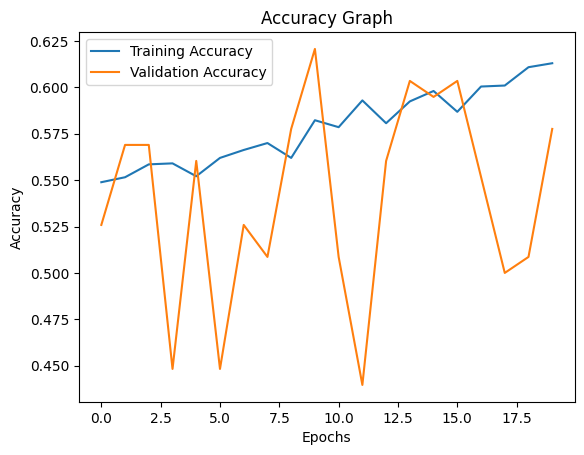

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Graph')
plt.legend()
plt.show()


In [1]:
loss, acc = model.evaluate(val_generator)
print("Final Validation Accuracy:", acc)


NameError: name 'model' is not defined